# Step 1: Import required libraries

In [ ]:
# Pandas is used for data handling
import pandas as pd
# Matplotlib is used for data visualization
import matplotlib.pyplot as plt

# Step 2: Load the dataset

In [ ]:
df = pd.read_excel("/content/Primary sales analysis.xlsx")


In [ ]:
# Display first few rows to understand the data
df.head()

,Invoice num,Invoice Date,Brand Name,Generic name,Pack size,Dosage,Therapy,Site,Group,EXI/NBD,Qty,Rate,Value
0,EG-2122-0002,2021-04-17,AMTOPID,Atorvastatin Tablets 10mg,10X10 Tablets Alu Alu Pack,Tablet,CVS,Kala Amb,Sales,Existing,44535,0.90,40081.50
1,EG-2122-0002,2021-04-17,SUMICEF,Omeprazole Delayed Release Capsules USP 20 mg,10X10 Alu Alu Strip,Capsule,Gastro,Kala Amb,Sales,Existing,33402,0.70,23381.40
2,EG-2122-0002,2021-04-17,AMNOTAC 150,Ranitidine Tablets USP 150 mg,10X10 Alu-Alu Strips Pack,Tablet,Gastro,P2P,Sales,Existing,37170,0.67,24903.90
3,EG-2122-0002,2021-04-17,AMNIPRED,Prednisolone 5Mg Tablet,10X10 Blister PVC,Tablet,Steroid,P2P,Sales,Existing,540,0.81,437.40
4,EG-2122-0002,2021-04-17,ANTAMYCIN INJECTION,Gentamicin Injection BP 80mg/2 mL,10X2ml Vial/Pack,Injection,Anti-Biotic,P2P,Sales,Existing,30121,0.75,22590.75


# Step 3: Data Cleaning


In [ ]:
# Check the data type of Invoice Date column
df['Invoice Date'].dtype

dtype('<M8[ns]')

In [ ]:
# Check for missing values in the dataset
df.isna().sum()

,0
Invoice num,0
Invoice Date,0
Brand Name,0
Generic name,21
Pack size,45
Dosage,0
Therapy,45
Site,0
Group,45
EXI/NBD,45


In [ ]:
# Fill missing Rate values with median
df['Rate'] = df['Rate'].fillna(df['Rate'].median())

df.isna().sum()

,0
Invoice num,0
Invoice Date,0
Brand Name,0
Generic name,21
Pack size,45
Dosage,0
Therapy,45
Site,0
Group,45
EXI/NBD,45


In [ ]:
# Check for duplicate rows
df.duplicated().sum()

np.int64(1)

In [ ]:
# Remove duplicate rows from the dataset
df = df.drop_duplicates()

df.duplicated().sum()

np.int64(0)

In [ ]:
# structure & data quality
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1282 entries, 0 to 1282
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Invoice num   1282 non-null   object        
 1   Invoice Date  1282 non-null   datetime64[ns]
 2   Brand Name    1282 non-null   object        
 3   Generic name  1261 non-null   object        
 4   Pack size     1237 non-null   object        
 5   Dosage        1282 non-null   object        
 6   Therapy       1237 non-null   object        
 7   Site          1282 non-null   object        
 8   Group         1237 non-null   object        
 9   EXI/NBD       1237 non-null   object        
 10  Qty           1282 non-null   int64         
 11  Rate          1282 non-null   float64       
 12  Value         1282 non-null   float64       
dtypes: datetime64[ns](1), float64(2), int64(1), object(9)
memory usage: 140.2+ KB


In [ ]:
# numeric insights
df.describe()

,Invoice Date,Qty,Rate,Value
count,1282,1282.000000,1282.000000,1282.000000
mean,2022-08-21 23:17:19.001560064,29551.964119,1.730101,29883.763042
min,2021-04-17 00:00:00,35.000000,0.000000,0.000000
25%,2021-12-27 00:00:00,9391.000000,0.600000,9771.400000
50%,2022-06-30 00:00:00,19672.000000,0.950000,19980.000000
75%,2023-04-27 00:00:00,39453.000000,2.350000,38479.300000
max,2023-12-30 00:00:00,280300.000000,50.000000,271603.800000
std,NaN,31480.138953,2.558218,31136.152584


# Step 4: Calculate total sales for each month

In [ ]:
# Grouping data by month and summing sales values
monthly_sales = df.groupby(df['Invoice Date'].dt.to_period('M'))['Value'].sum()

# Convert Period format to a regular column
monthly_sales = monthly_sales.reset_index()

# Convert date to string format for plotting
monthly_sales['Invoice Date'] = monthly_sales['Invoice Date'].astype(str)

# Display monthly sales data
monthly_sales

,Invoice Date,Value
0,2021-04,303956.20
1,2021-05,538092.20
2,2021-06,786579.80
3,2021-07,703240.45
4,2021-08,2852965.77
5,2021-09,1812151.78
6,2021-10,1377394.26
7,2021-11,908124.89
8,2021-12,1391425.56
9,2022-01,1301245.50


# Step 5: Create a month index

In [ ]:
# This index helps the model understand the time sequence
monthly_sales['Month_Index'] = range(len(monthly_sales))

# Step 6: Apply a simple Linear Regression model

In [ ]:
# This model helps identify the overall sales trend
from sklearn.linear_model import LinearRegression

# Independent variable (time index)
X = monthly_sales[['Month_Index']]

# Dependent variable (sales value)
y = monthly_sales['Value']

# Create and train the model
model = LinearRegression()
model.fit(X, y)

LinearRegression()

# Step 7: Predict sales for the next 3 months

In [ ]:
# Create future month index values
future_index = pd.DataFrame({
    'Month_Index': [
        len(monthly_sales),
        len(monthly_sales) + 1,
        len(monthly_sales) + 2
    ]
})

# Predict future sales values
future_sales = model.predict(future_index)

# Store predicted values in a DataFrame
future_df = pd.DataFrame({
    'Month': ['Next Month 1', 'Next Month 2', 'Next Month 3'],
    'Projected Sales': future_sales
})

# Display forecasted sales
future_df

,Month,Projected Sales
0,Next Month 1,1.216593e+06
1,Next Month 2,1.219866e+06
2,Next Month 3,1.223140e+06


# Step 8: Plot historical sales and forecasted sales

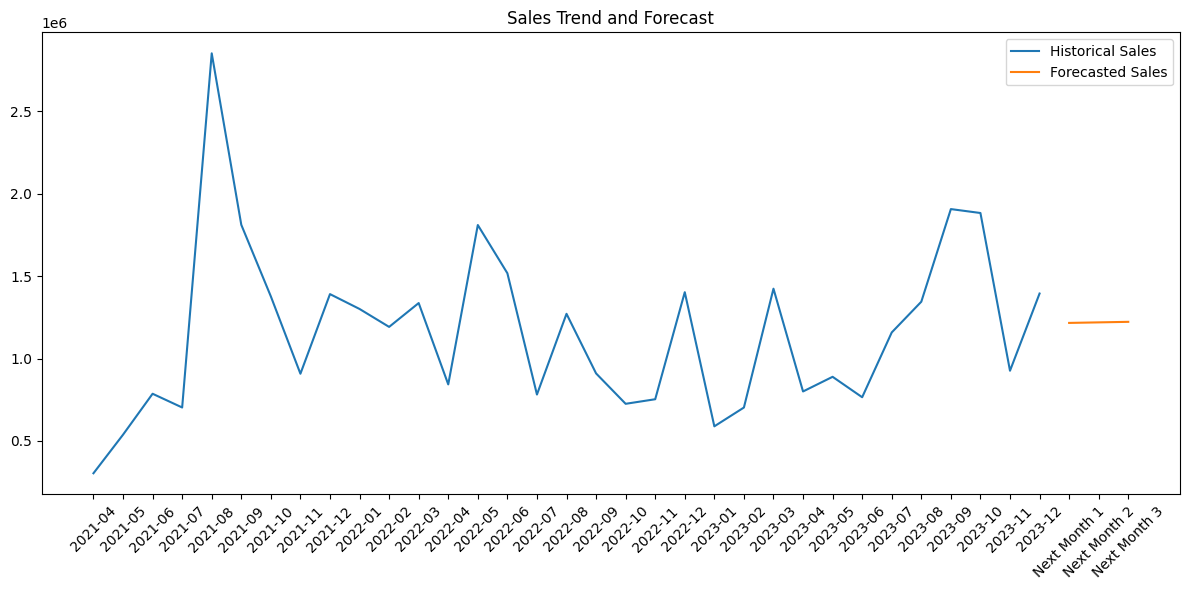

In [ ]:
# Set figure size to avoid overlap
plt.figure(figsize=(12, 6))

# Plot historical sales data
plt.plot(
    monthly_sales['Invoice Date'],
    monthly_sales['Value'],
    label='Historical Sales'
)

# Plot forecasted sales data
plt.plot(
    future_df['Month'],
    future_df['Projected Sales'],
    label='Forecasted Sales'
)

# Rotate x-axis labels for better readability
plt.xticks(rotation=45)

# Add chart title (unchanged)
plt.title('Sales Trend and Forecast')

# Show legend
plt.legend()

# Adjust layout to prevent cutting
plt.tight_layout()

# Display the plot
plt.show()